# Notebook 01 — Data Collection & Literature Review
## The 15-Minute Shanghai Project · Track C — Affordability

**Research question.** *Is the 15-minute city in Shanghai a privilege of the wealthy, or do corridors of high amenity access combined with low housing cost exist?*

---

## Literature Review

### 1. The concept and its essential urban functions
The "15-minute city" was formalised by **Moreno et al. (2021)** in *Smart Cities*, who define it as an urban model in which residents can reach the services that sustain daily life within a quarter-hour walk or cycle from home. The authors organise these services around **six essential social functions** — *living, working, commerce, healthcare, education, and entertainment* — and propose four constituent dimensions (density, proximity, diversity, and digitalisation). This functional decomposition is important methodologically: it converts a vague slogan into a measurable checklist of need categories that any operationalisation must instantiate. The present project adopts a six-need adaptation of this framework (food/daily retail, healthcare, education, employment, leisure/sport/culture, and public services), which we ground not only in Moreno's typology but in a locally authoritative source described below.

### 2. From concept to local standard: Shanghai's "Community Life Circle"
China developed a strikingly parallel planning instrument before the Moreno framework gained global traction. The **Shanghai 15-Minute Community Life Circle Planning Guidelines** (*上海市15分钟社区生活圈规划导则*, Shanghai Municipal Bureau of Planning and Natural Resources, 2016), embedded in the Shanghai Master Plan 2017–2035, prescribes the categories of facilities — basic education, healthcare, daily retail, culture and sport, green/public space, and administrative services — that should lie within a 15-minute pedestrian radius of every residential community. Because our study area *is* Shanghai, this document is the strongest justification for our category selection: it is the official, jurisdiction-specific definition of what a 15-minute neighbourhood must contain, and it aligns closely with Moreno's six functions while reflecting Chinese public-service provision norms. Yang & Qian (2024) further show, through bibliometric analysis, that the "life circle" (生活圈) and "15-minute city" literatures have largely converged, validating the use of Western conceptual frameworks alongside the Chinese policy standard.

### 3. Measurement methodology and its pitfalls
Operationalising accessibility is non-trivial. **Pozoukidou & Chatziyiannaki (2021)**, in *Sustainability* ("Decomposing the New Urban Planning Eutopia"), review measurement approaches and warn that the model's appeal can outrun its analytical rigour: results depend heavily on (i) how travel time is computed, (ii) which amenities are counted, and (iii) the spatial unit of analysis. A recurring methodological fault line is **Euclidean (straight-line) buffers versus network-based distances**: Euclidean proximity systematically overstates access because it ignores street connectivity, rivers, and barriers — a serious concern in Shanghai, which is bisected by the Huangpu River and numerous canals. Following best practice, this project therefore computes **network-based isochrones** over a real pedestrian/cycling graph rather than circular buffers, and it aggregates results to **Uber H3 hexagons (resolution 8)** to provide a consistent, area-normalised spatial unit. The cumulative-opportunity logic (counting how many of the six needs are reachable within 15 minutes) follows the dominant convention in the empirical literature.

### 4. The equity critique — the core of Track C
The most important strand for this project is the **equity critique**. The 15-minute city is frequently presented as inherently progressive, yet scholars caution that amenity-rich, walkable neighbourhoods are precisely those that command the highest land values, so a naïve "accessibility score" may simply re-describe wealth. **Weng et al. (2019)**, in the *Journal of Transport & Health*, provide the key empirical anchor: measuring 15-minute walkable neighbourhoods across urban China (with Shanghai-relevant evidence), they document **systematic social inequalities** in access to basic services, with peripheral and lower-income populations under-served. This finding motivates our central analytical move: we deliberately **cross accessibility with housing cost** (per-m² prices from the Gaode `房价数据` layer and Anjuke listings) rather than reporting access alone. Doing so reframes the question from "where is access high?" to "where is access high *relative to* what residents must pay?" — exposing whether the 15-minute ideal is being delivered equitably or is, as critics fear, a marker of privilege. The risk of induced gentrification noted by Pozoukidou & Chatziyiannaki reinforces why an affordability lens, not an access lens alone, is the policy-relevant framing for Shanghai.

### 5. Synthesis and implications for this notebook
Taken together, the literature dictates concrete design choices implemented below: (a) a **six-need taxonomy** justified by Moreno (2021) and the Shanghai Guidelines (2016); (b) **network-based** rather than Euclidean accessibility (Pozoukidou & Chatziyiannaki, 2021); (c) **H3 aggregation** for comparability; and (d) an **affordability cross-tabulation** responding directly to the equity evidence of Weng et al. (2019). This first notebook assembles and validates the raw inputs — Gaode/AMap POIs, the dedicated 2026 education dataset, housing prices, and transit — that the subsequent notebooks transform into accessibility scores and an equity-aware "where to live" recommendation.

### References
- Moreno, C., Allam, Z., Chabaud, D., Gall, C., & Pratlong, F. (2021). *Introducing the "15-Minute City": Sustainability, Resilience and Place Identity in Future Post-Pandemic Cities.* **Smart Cities, 4(1), 93–111.** https://doi.org/10.3390/smartcities4010006
- Pozoukidou, G., & Chatziyiannaki, Z. (2021). *15-Minute City: Decomposing the New Urban Planning Eutopia.* **Sustainability, 13(2), 928.** https://doi.org/10.3390/su13020928
- Weng, M., Ding, N., Li, J., Jin, X., Xiao, H., He, Z., & Su, S. (2019). *The 15-minute walkable neighborhoods: Measurement, social inequalities and implications for building healthy communities in urban China.* **Journal of Transport & Health, 13, 259–273.** https://doi.org/10.1016/j.jth.2019.05.005
- Shanghai Municipal Bureau of Planning and Natural Resources (2016). *Shanghai 15-Minute Community Life Circle Planning Guidelines (上海市15分钟社区生活圈规划导则).*
- Yang, C., & Qian, Z. (2024). *The new paradigm of future cities? Facilitating dialogues between the 15-minute city and the 15-minute life circle in China based on a bibliometric analysis.* **Urban Planning International.**


## 1. Environment & configuration
Reusable paths and helpers live in `../src` (`config.py`, `geo_utils.py`).

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np
import pandas as pd
import geopandas as gpd
from config import (SHP_2024, EDU_2026, ANJUKE, DATA_CLEAN, SHANGHAI_BBOX,
                    NEEDS_LAYERS)
from geo_utils import gcj02_to_wgs84
warnings.filterwarnings("ignore")
DATA_CLEAN.mkdir(parents=True, exist_ok=True)

WGS84 = "EPSG:4326"
METRIC = "EPSG:32651"   # UTM 51N, pour les distances en mètres (Shanghai)
KEEP = ["name", "typecode", "行业大", "行业中", "行业小", "adname"]
print("Bounding box étude (WGS84):", SHANGHAI_BBOX)

Bounding box étude (WGS84): (120.85, 30.67, 122.25, 31.88)


## 2. Baseline POI — five universal needs (Gaode/AMap 2024)
We load five of the six needs from the master 2024 shapefiles (education is handled separately in §3,
because the instructor flagged a problem with the 2024 education layer). Reading is restricted to the
study bounding box and to the columns we need, which keeps memory and time low despite multi-GB attribute tables.

In [2]:
def load_need(need, patterns):
    frames = []
    for pat in patterns:
        for shp in sorted(SHP_2024.glob(pat)):
            if shp.suffix.lower() != ".shp":   # le glob *cat* capture aussi .dbf/.cpg/.shx
                continue
            g = gpd.read_file(shp, engine="pyogrio", columns=KEEP, bbox=SHANGHAI_BBOX)
            g["need"] = need
            frames.append(g)
    out = pd.concat(frames, ignore_index=True)
    return gpd.GeoDataFrame(out, geometry="geometry", crs=WGS84)

need_gdfs = []
for need, patterns in NEEDS_LAYERS.items():
    g = load_need(need, patterns)
    need_gdfs.append(g)
    print(f"{need:14} {len(g):>8,} POI")
poi_baseline = pd.concat(need_gdfs, ignore_index=True)
poi_baseline = gpd.GeoDataFrame(poi_baseline, geometry="geometry", crs=WGS84)
print("\nTotal baseline POI:", f"{len(poi_baseline):,}")

alimentation    340,373 POI


sante            23,135 POI


emploi          145,322 POI


loisir_sport     46,331 POI


services        178,382 POI

Total baseline POI: 733,543


## 3. Education — EDU 2026 dataset (GCJ-02 → WGS84)
The instructor warned that the **2024 education data has a problem**, so we use the dedicated **EDU 2026**
collection (AMap WebService API, 4,143 schools: kindergarten, primary, junior/senior high). These records are
in **GCJ-02** (China's offset datum) and must be converted to WGS84. We validate the conversion by nearest-neighbour
distance to the 2024 science/education POIs: the *converted* points should sit essentially on top of them.

In [3]:
edu = pd.read_csv(EDU_2026 / "preschool_k12_clean.csv")
wlng, wlat = gcj02_to_wgs84(edu["lng"].values, edu["lat"].values)
edu_g = gpd.GeoDataFrame(
    pd.DataFrame({
        "name": edu["name"], "typecode": edu["typecode"].astype(str),
        "行业大": "科教文化服务", "行业中": edu["category"], "行业小": edu.get("type"),
        "adname": edu["district"], "need": "education",
    }),
    geometry=gpd.points_from_xy(wlng, wlat), crs=WGS84,
)
print("Écoles EDU 2026:", f"{len(edu_g):,}")
print(edu_g["行业中"].value_counts())

# --- validation CRS : distance médiane aux POI éducation 2024 ---
sci = gpd.read_file(SHP_2024 / "上海市_科教文化服务.shp", engine="pyogrio",
                    columns=["name"], bbox=SHANGHAI_BBOX).to_crs(METRIC)
chk = edu_g.to_crs(METRIC).sample(min(300, len(edu_g)), random_state=0)
nn = gpd.sjoin_nearest(chk, sci, how="left", distance_col="d")
print(f"\nValidation CRS — distance médiane école↔POI éduc 2024 : {nn['d'].median():.0f} m "
      f"({'OK alignement' if nn['d'].median() < 50 else 'À VÉRIFIER'})")

Écoles EDU 2026: 4,143
行业中
幼儿园    2021
小学      999
中学      938
高中       99
初中       86
Name: count, dtype: int64



Validation CRS — distance médiane école↔POI éduc 2024 : 0 m (OK alignement)


## 4. Unify & validate the POI base
Merge the five baseline needs with education into a single tidy layer, drop duplicates, clip to the study area.

In [4]:
poi = pd.concat([poi_baseline, edu_g], ignore_index=True)
poi = gpd.GeoDataFrame(poi, geometry="geometry", crs=WGS84)

# nettoyage : géométries valides non vides, dans la bbox
poi = poi[poi.geometry.notna() & ~poi.geometry.is_empty]
minx, miny, maxx, maxy = SHANGHAI_BBOX
poi = poi.cx[minx:maxx, miny:maxy]
# representative_point() => Point garanti pour tout type de géométrie (gère les MultiPoint)
pts = poi.geometry.representative_point()
poi["lon"] = pts.x.values; poi["lat"] = pts.y.values
# dédoublonnage (need + name + position arrondie ~1 m)
poi["_rx"] = poi["lon"].round(5); poi["_ry"] = poi["lat"].round(5)
before = len(poi)
poi = poi.drop_duplicates(subset=["need", "name", "_rx", "_ry"]).drop(columns=["_rx", "_ry"])
print(f"Dédoublonnage : {before:,} -> {len(poi):,}")

summary = poi.groupby("need").size().rename("count").reset_index().sort_values("count", ascending=False)
print("\nPOI par besoin :"); print(summary.to_string(index=False))

Dédoublonnage : 737,686 -> 737,159

POI par besoin :
        need  count
alimentation 340353
    services 177899
      emploi 145318
loisir_sport  46328
       sante  23125
   education   4136


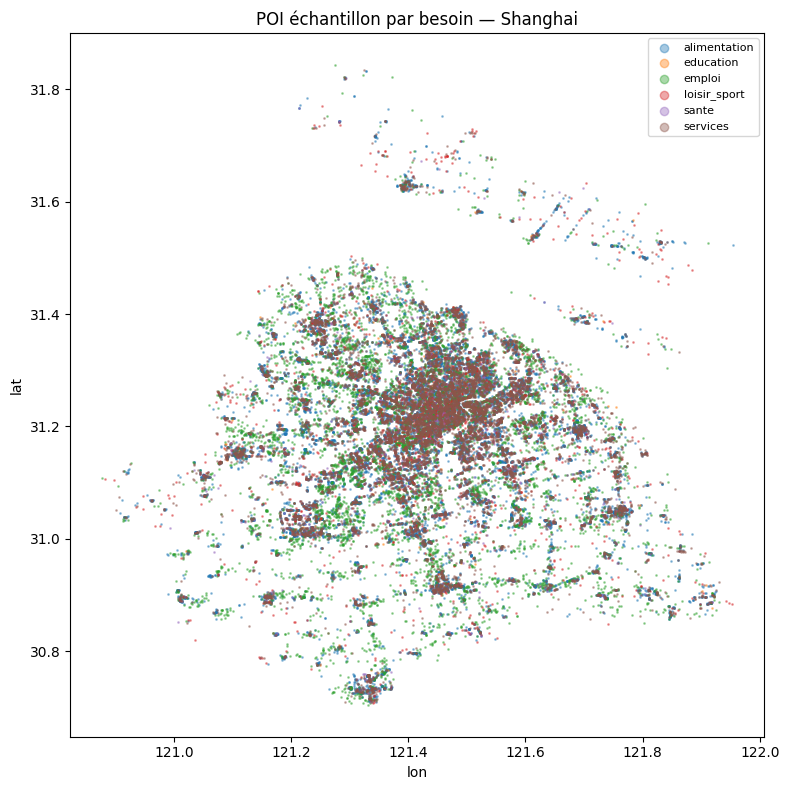

In [5]:
# carte de validation (échantillon)
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 8))
    samp = poi.sample(min(40000, len(poi)), random_state=1)
    for need, sub in samp.groupby("need"):
        ax.scatter(sub["lon"], sub["lat"], s=1, alpha=0.4, label=need)
    ax.set_title("POI échantillon par besoin — Shanghai"); ax.legend(markerscale=6, fontsize=8)
    ax.set_xlabel("lon"); ax.set_ylabel("lat"); plt.tight_layout(); plt.show()
except Exception as e:
    print("plot skipped:", e)

## 5. Housing prices — `房价数据` + Anjuke
Two complementary per-m² price sources. The Gaode `房价数据` layer stores the price as text (e.g. `"117450 元/㎡"`),
which we parse to a numeric ¥/m². Anjuke provides an independent set of listings with a precomputed metro distance
(`dist_metro_m`) that we reuse for the affordability regression in notebook 03.

In [6]:
# --- 房价数据 (Gaode) ---
price_shp = gpd.read_file(SHP_2024 / "上海市_房价数据.shp", engine="pyogrio", bbox=SHANGHAI_BBOX)
price_shp["price_per_m2"] = (price_shp["小区2022"].astype(str)
                             .str.replace(r"[^0-9]", "", regex=True).replace("", np.nan).astype(float))
gaode_price = price_shp.loc[price_shp["price_per_m2"].between(1000, 400000),
                            ["小区名", "物业类", "竣工时", "price_per_m2", "geometry"]].copy()
gaode_price = gaode_price.rename(columns={"小区名": "name", "物业类": "ptype", "竣工时": "built"})
gaode_price["source"] = "gaode_fangjia"

# --- Anjuke (parquet pandas : géométrie WKB brute -> on reconstruit depuis lon/lat) ---
anj = pd.read_parquet(ANJUKE).drop(columns=["geometry"], errors="ignore")
anj = gpd.GeoDataFrame(anj, geometry=gpd.points_from_xy(anj.longitude, anj.latitude), crs=WGS84)
anjuke_price = anj.rename(columns={"onesquaremeter": "price_per_m2", "district": "adname"})[
    ["price_per_m2", "dist_metro_m", "adname", "geometry"]].copy()
anjuke_price["source"] = "anjuke"

print(f"Gaode 房价数据 : {len(gaode_price):,} résidences | médiane {gaode_price.price_per_m2.median():,.0f} ¥/m²")
print(f"Anjuke         : {len(anjuke_price):,} logements  | médiane {anjuke_price.price_per_m2.median():,.0f} ¥/m²")

Gaode 房价数据 : 17,728 résidences | médiane 60,976 ¥/m²
Anjuke         : 9,743 logements  | médiane 56,018 ¥/m²


## 6. Transit — metro & bus
Light reference layers for the transit travel mode (used as a bonus mode in scoring).

In [7]:
metro = gpd.read_file(SHP_2024 / "上海市_地铁站.shp", engine="pyogrio", bbox=SHANGHAI_BBOX)
metro = metro.rename(columns={"PointName": "name", "LineName": "line"})[["name", "line", "geometry"]]
metro["mode"] = "metro"
bus = gpd.read_file(SHP_2024 / "上海市_公交车站.shp", engine="pyogrio",
                    columns=["name", "adname"], bbox=SHANGHAI_BBOX)
bus["mode"] = "bus"
transit = pd.concat([metro, bus], ignore_index=True)
transit = gpd.GeoDataFrame(transit, geometry="geometry", crs=WGS84)
print(f"Métro: {len(metro):,} stations | Bus: {len(bus):,} arrêts")

Métro: 1,498 stations | Bus: 17,221 arrêts


## 7. Export clean datasets
Compact GeoParquet files consumed by notebooks 02–03.

In [8]:
poi.to_parquet(DATA_CLEAN / "poi.parquet")
prices = pd.concat([gaode_price, anjuke_price], ignore_index=True)
prices = gpd.GeoDataFrame(prices, geometry="geometry", crs=WGS84)
prices.to_parquet(DATA_CLEAN / "prices.parquet")
transit.to_parquet(DATA_CLEAN / "transit.parquet")
for f in ["poi.parquet", "prices.parquet", "transit.parquet"]:
    p = DATA_CLEAN / f
    print(f"  saved {f:18} {p.stat().st_size/1e6:6.1f} MB")

  saved poi.parquet          44.3 MB
  saved prices.parquet        1.0 MB
  saved transit.parquet       0.6 MB


## 8. Data sources & transparency
| Dataset | Source | Year | CRS (native→used) | Role |
|---|---|---|---|---|
| POI by category | Gaode / AMap (SHP) | 2024 | WGS84 | 5 baseline needs |
| Education POI | Gaode / AMap WebService API | 2026 | GCJ-02 → WGS84 | education need |
| `房价数据` housing price | Gaode / AMap (SHP) | 2022–24 | WGS84 | affordability |
| Anjuke listings | Anjuke (安居客) | prior project | WGS84 | affordability + metro distance |
| Metro / bus | Gaode / AMap (SHP) | 2024 | WGS84 | transit mode |

**Known limitations.** POI presence ≠ quality/capacity; `房价数据` prices are asking prices, not transactions; the
2024 education layer was excluded on instructor advice; coverage thins in outer rural districts. All layers reprojected
to EPSG:4326 and clipped to the study bounding box.